# 01 — Data Understanding

**Milestone 1 tickets covered:** `HC-M1-02` (dataset structure analysis), `HC-M1-03` (data quality assessment), `HC-M1-04` (target distribution).

See [`docs/problem_definition.md`](../docs/problem_definition.md) for the business problem, target definition, and metric choice — this notebook does not repeat that context.

**Source of truth for everything below:** [`reports/data_dictionary.md`](../reports/data_dictionary.md), [`reports/data_quality_summary.md`](../reports/data_quality_summary.md) (duplicates + every foreign-key relationship, one row per table), and [`reports/data_profile/*.json`](../reports/data_profile/) — all produced by `scripts/profile_data.py` (full-table DuckDB aggregates — exact counts, not samples) and `scripts/generate_data_quality_summary.py`. This notebook loads those artifacts rather than `pd.read_csv()`-ing the raw files, and only drops into a couple of targeted DuckDB queries for things genuinely outside the profile's scope (the train/test schema diff, and the `DAYS_EMPLOYED` sentinel breakdown by income type). That keeps this notebook fast and reproducible regardless of how large the underlying files are.

This is understanding only — no cleaning, imputing, or feature engineering happens here.

In [6]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

PROFILE_DIR = Path("../reports/data_profile")
CACHE_DB = PROFILE_DIR / ".landing_cache.duckdb"

profiles = {}
for path in sorted(PROFILE_DIR.glob("*.json")):
    profile = json.loads(path.read_text())
    profiles[path.stem] = profile

print(f"Loaded {len(profiles)} table profiles: {list(profiles)}")

Loaded 9 table profiles: ['POS_CASH_balance', 'application_test', 'application_train', 'bureau', 'bureau_balance', 'credit_card_balance', 'installments_payments', 'previous_application', 'sample_submission']


## Table inventory — row/column counts, keys, dtype mix

Row and column counts, the numeric/categorical split, and the primary-key / foreign-key integrity checks below are all read directly from the profile JSON — every number here comes from a full-table scan done once by `scripts/profile_data.py`, not from a sample.

In [7]:
def numeric_categorical_split(profile: dict) -> tuple[int, int]:
    numeric = sum(1 for e in profile["columns"].values() if "min" in e)
    categorical = profile["column_count"] - numeric
    return numeric, categorical


rows = []
for profile in profiles.values():
    numeric, categorical = numeric_categorical_split(profile)
    pk = profile.get("primary_key_check")
    rows.append(
        {
            "table": profile["table"],
            "rows": profile["row_count"],
            "columns": profile["column_count"],
            "numeric_cols": numeric,
            "categorical_cols": categorical,
            "primary_key": pk["column"] if pk else None,
            "pk_unique": pk["is_unique"] if pk else None,
            "duplicate_rows": profile["duplicate_row_check"]["duplicate_row_count"],
        }
    )

inventory = (
    pd.DataFrame(rows).sort_values("rows", ascending=False).reset_index(drop=True)
)
inventory

,table,rows,columns,numeric_cols,categorical_cols,primary_key,pk_unique,duplicate_rows
0,bureau_balance.csv,27299925,3,2,1,NaN,None,0
1,installments_payments.csv,13605401,8,8,0,NaN,None,0
2,POS_CASH_balance.csv,10001358,8,7,1,NaN,None,0
3,credit_card_balance.csv,3840312,23,22,1,NaN,None,0
4,bureau.csv,1716428,17,14,3,SK_ID_BUREAU,True,0
5,previous_application.csv,1670214,37,21,16,SK_ID_PREV,True,0
6,application_train.csv,307511,122,106,16,SK_ID_CURR,True,0
7,application_test.csv,48744,121,105,16,SK_ID_CURR,True,0
8,sample_submission.csv,48744,2,2,0,NaN,None,0


### Relationships between tables

The spine of the whole schema is `SK_ID_CURR` (one row = one loan application in `application_train`/`application_test`). Everything else fans out from it:

- **`application_train` / `application_test`** — grain: one row per `SK_ID_CURR`. `SK_ID_CURR` is a verified-unique primary key in both (see `pk_unique` above). `application_test` has no `TARGET` — it is Kaggle's blind scoring set, not a validation set we control.
- **`bureau`** — one row per previous credit reported to the credit bureau. Own primary key `SK_ID_BUREAU` (unique), foreign key `SK_ID_CURR` back to the spine — **0 orphans**, every bureau record resolves to a known applicant.
- **`bureau_balance`** — one row per `(SK_ID_BUREAU, MONTHS_BALANCE)`, i.e. a monthly snapshot of a bureau credit. **It has no `SK_ID_CURR` column at all** — to attach it to an applicant it must be joined through `bureau` first (`bureau_balance.SK_ID_BUREAU → bureau.SK_ID_BUREAU → bureau.SK_ID_CURR`). See the referential integrity section below — this join is not perfectly clean.
- **`previous_application`** — one row per previous Home Credit application. Own primary key `SK_ID_PREV` (unique), foreign key `SK_ID_CURR` — **0 orphans**.
- **`POS_CASH_balance`, `credit_card_balance`, `installments_payments`** — monthly/event-level history of previous credits, keyed by `(SK_ID_PREV, MONTHS_BALANCE)` or `(SK_ID_PREV, installment number)` respectively; no single-column primary key (that's expected — the grain is inherently multi-row per previous application). Each has **two** foreign keys: `SK_ID_CURR` back to the spine (**0 orphans** in all three) and `SK_ID_PREV` back to `previous_application` — **not clean**, see below.

Net effect for later feature engineering: aggregating the previous-credit tables up to one row per `SK_ID_CURR` (via `groupby(SK_ID_CURR).agg(...)`) is the natural join strategy — never join them directly onto `application_*` at their native grain, that would fan out `application_train`'s one-row-per-applicant grain.

### Referential integrity & duplicates

`scripts/profile_data.py` persists a full-row duplicate check and **every** declared foreign-key relationship for every table — not just "this column → the `SK_ID_CURR` spine" as before, but arbitrary table-to-table relationships (`bureau_balance → bureau`, and now `SK_ID_PREV` on the three previous-credit history tables → `previous_application`, which had never been checked until this pass). `scripts/generate_data_quality_summary.py` consolidates all of it into one scorecard. Rendered directly below — no ad hoc queries needed, this is exactly the artifact meant to answer "how much duplicate/bad data is in all my tables" at a glance, for a human or a future session, without reading notebook code.

In [8]:
from IPython.display import Markdown, display

scorecard_path = Path("../reports/data_quality_summary.md")
display(Markdown(scorecard_path.read_text()))

# Data Quality Scorecard — Home Credit Default Risk

Generated from `reports/data_profile/*.json` by `scripts/generate_data_quality_summary.py`. Regenerate after re-running `scripts/profile_data.py`. One row per table, every number a full-table DuckDB scan — not a sample.

| Table | Rows | Duplicate rows | PK check | FK orphan checks | Worst missing column | Constant columns |
| --- | --- | --- | --- | --- | --- | --- |
| `POS_CASH_balance.csv` | 10,001,358 | 0 | — | SK_ID_CURR→spine.SK_ID_CURR: 0 orphans; SK_ID_PREV→previous_application.SK_ID_PREV: 37422 orphans | CNT_INSTALMENT_FUTURE (0.2608%) | 0 |
| `application_test.csv` | 48,744 | 0 | SK_ID_CURR: 0 dup keys | — | COMMONAREA_AVG (68.7161%) | 11 |
| `application_train.csv` | 307,511 | 0 | SK_ID_CURR: 0 dup keys | — | COMMONAREA_AVG (69.8723%) | 0 |
| `bureau.csv` | 1,716,428 | 0 | SK_ID_BUREAU: 0 dup keys | SK_ID_CURR→spine.SK_ID_CURR: 0 orphans | AMT_ANNUITY (71.4735%) | 0 |
| `bureau_balance.csv` | 27,299,925 | 0 | — | SK_ID_BUREAU→bureau.SK_ID_BUREAU: 43041 orphans | — | 0 |
| `credit_card_balance.csv` | 3,840,312 | 0 | — | SK_ID_CURR→spine.SK_ID_CURR: 0 orphans; SK_ID_PREV→previous_application.SK_ID_PREV: 11372 orphans | AMT_PAYMENT_CURRENT (19.9981%) | 0 |
| `installments_payments.csv` | 13,605,401 | 0 | — | SK_ID_CURR→spine.SK_ID_CURR: 0 orphans; SK_ID_PREV→previous_application.SK_ID_PREV: 38847 orphans | DAYS_ENTRY_PAYMENT (0.0214%) | 0 |
| `previous_application.csv` | 1,670,214 | 0 | SK_ID_PREV: 0 dup keys | SK_ID_CURR→spine.SK_ID_CURR: 0 orphans | RATE_INTEREST_PRIMARY (99.6437%) | 0 |
| `sample_submission.csv` | 48,744 | 0 | — | — | — | 1 |


**Findings, all surfaced directly by the scorecard above:**

- `bureau_balance → bureau`: **43,041 orphan `SK_ID_BUREAU`** values (~5.3% of 817,395 distinct IDs) — a naive join silently drops this history before it reaches an applicant.
- **New, previously unchecked**: `SK_ID_PREV` orphans against `previous_application` — `POS_CASH_balance` 4.00%, `installments_payments` 3.89%, and `credit_card_balance` **10.90%** (the worst of the three). None of this was visible before this scorecard existed — it only surfaced by generalizing the profiler's foreign-key check beyond "column → spine."
- All 9 tables show **0 full-row duplicates**.

Nothing is fixed here — flagged for the feature engineering stage, per this notebook's "understand, don't fix" scope.

### Train vs. test differences

In [9]:
con = duckdb.connect(str(CACHE_DB), read_only=True)

train_columns = {row[0] for row in con.sql("DESCRIBE application_train").fetchall()}
test_columns = {row[0] for row in con.sql("DESCRIBE application_test").fetchall()}

print("Columns in train but not test:", train_columns - test_columns)
print("Columns in test but not train:", test_columns - train_columns)
print(
    f"application_train: {profiles['application_train']['column_count']} columns, "
    f"application_test: {profiles['application_test']['column_count']} columns"
)

Columns in train but not test: {'TARGET'}
Columns in test but not train: set()
application_train: 122 columns, application_test: 121 columns


The only schema difference is `TARGET` — expected, since it's the label we're predicting. Every feature column that exists in train also exists in test, so nothing needs to be dropped for a train/test mismatch.

## Data quality assessment (HC-M1-03)

This section only characterizes data quality issues — nothing is imputed, dropped, or transformed here. That happens later, inside a `Pipeline`, fit on the training split only.

### Missing values — worst offenders per table

In [10]:
missing_rows = []
for profile in profiles.values():
    for col, entry in profile["columns"].items():
        if entry["null_pct"]:
            missing_rows.append(
                {
                    "table": profile["table"],
                    "column": col,
                    "null_pct": entry["null_pct"],
                }
            )

missing_df = pd.DataFrame(missing_rows)
top_missing = (
    missing_df.sort_values("null_pct", ascending=False)
    .groupby("table")
    .head(3)
    .sort_values(["table", "null_pct"], ascending=[True, False])
    .reset_index(drop=True)
)
top_missing

,table,column,null_pct
0,POS_CASH_balance.csv,CNT_INSTALMENT_FUTURE,0.2608
1,POS_CASH_balance.csv,CNT_INSTALMENT,0.2607
2,application_test.csv,COMMONAREA_MEDI,68.7161
3,application_test.csv,COMMONAREA_MODE,68.7161
4,application_test.csv,COMMONAREA_AVG,68.7161
5,application_train.csv,COMMONAREA_MEDI,69.8723
6,application_train.csv,COMMONAREA_AVG,69.8723
7,application_train.csv,COMMONAREA_MODE,69.8723
8,bureau.csv,AMT_ANNUITY,71.4735
9,bureau.csv,AMT_CREDIT_MAX_OVERDUE,65.5133


`application` has several columns above 60% missing (the `COMMONAREA_*` building-metadata fields) — worth flagging now, decided on later (drop vs. missingness-as-signal) once we're inside the modeling pipeline. `bureau`'s `AMT_ANNUITY` and `previous_application`'s `RATE_INTEREST_*` are near-fully missing (>65-99%), which is a strong signal those `RATE_INTEREST_*` columns are close to unusable as-is.

### Constant / near-constant columns

A column with only one distinct value carries no signal for any model — worth knowing before feature engineering, not worth acting on yet.

In [11]:
constant_rows = []
for profile in profiles.values():
    for col, entry in profile["columns"].items():
        if entry["distinct_count"] <= 1:
            constant_rows.append({"table": profile["table"], "column": col})

pd.DataFrame(constant_rows)

,table,column
0,application_test.csv,FLAG_DOCUMENT_2
1,application_test.csv,FLAG_DOCUMENT_10
2,application_test.csv,FLAG_DOCUMENT_12
3,application_test.csv,FLAG_DOCUMENT_13
4,application_test.csv,FLAG_DOCUMENT_14
5,application_test.csv,FLAG_DOCUMENT_15
6,application_test.csv,FLAG_DOCUMENT_16
7,application_test.csv,FLAG_DOCUMENT_17
8,application_test.csv,FLAG_DOCUMENT_19
9,application_test.csv,FLAG_DOCUMENT_20


**Finding:** in `application_test`, eleven `FLAG_DOCUMENT_*` columns are constant (always the same value) — but they vary in `application_train`. That's a real train/test distribution shift on those specific flags, not a bug in the profiler: worth a second look before trusting those features to generalize, since a flag that never varies in the columns available for scoring can't contribute to ranking test applicants regardless of what it does on cross-validation. `sample_submission.csv`'s `TARGET` column being constant is expected — it's Kaggle's placeholder column, not real data.

### Suspicious values — the `DAYS_EMPLOYED` sentinel

All `DAYS_*` columns in `application_*` are "days relative to the application date," so genuine values are small negative integers. The profile's numeric stats already hint at a problem in one of them:

In [12]:
days_employed = profiles["application_train"]["columns"]["DAYS_EMPLOYED"]
print(json.dumps(days_employed, indent=2))

sentinel_count = con.sql(
    "SELECT COUNT(*) FROM application_train WHERE DAYS_EMPLOYED = 365243"
).fetchone()[0]
total = profiles["application_train"]["row_count"]
sentinel_pct = 100 * sentinel_count / total
print(f"\nRows at sentinel (365243): {sentinel_count:,} ({sentinel_pct:.2f}%)")

{
  "dtype": "BIGINT",
  "null_count": 0,
  "null_pct": 0.0,
  "distinct_count": 12574,
  "min": -17912,
  "max": 365243,
  "avg": 63815.04590404896,
  "median": -1213.0
}

Rows at sentinel (365243): 55,374 (18.01%)


In [13]:
sentinel_by_income_type = con.sql(
    """
    SELECT NAME_INCOME_TYPE, COUNT(*) AS n
    FROM application_train
    WHERE DAYS_EMPLOYED = 365243
    GROUP BY 1 ORDER BY 2 DESC
    """
).df()
sentinel_by_income_type

,NAME_INCOME_TYPE,n
0,Pensioner,55352
1,Unemployed,22


**Confirmed: `DAYS_EMPLOYED = 365243` (~1000 years) is a sentinel for "not currently employed," not a real value.** 18.0% of applicants hit this exact value, and it is almost entirely `NAME_INCOME_TYPE = 'Pensioner'` (55,352 of 55,374 rows). Left untreated, this single value would drag the column's mean far above its true range (the profile's `avg` of 63,815 vs. a `median` of -1,213 already shows the distortion) and would corrupt any model that uses `DAYS_EMPLOYED` as a plain numeric feature — a tree-based model might isolate it as its own split, but a linear model or a distance-based one would treat it as a legitimate outlier. **Fix deferred to feature engineering** (recode as missing + add an `is_pensioner`/`employment_unknown` flag), consistent with this notebook's "understand, don't fix" scope.

### Categorical cardinality

In [14]:
categorical_rows = []
for profile in profiles.values():
    for col, entry in profile["columns"].items():
        if "top_values" in entry or (entry["dtype"] == "VARCHAR"):
            categorical_rows.append(
                {
                    "table": profile["table"],
                    "column": col,
                    "distinct_count": entry["distinct_count"],
                    "has_top_values": "top_values" in entry,
                }
            )

categorical_df = pd.DataFrame(categorical_rows).sort_values(
    "distinct_count", ascending=False
)
categorical_df.head(15)

,table,column,distinct_count,has_top_values
28,application_train.csv,ORGANIZATION_TYPE,58,True
12,application_test.csv,ORGANIZATION_TYPE,58,True
47,previous_application.csv,NAME_GOODS_CATEGORY,28,True
41,previous_application.csv,NAME_CASH_LOAN_PURPOSE,25,True
10,application_test.csv,OCCUPATION_TYPE,18,True
26,application_train.csv,OCCUPATION_TYPE,18,True
53,previous_application.csv,PRODUCT_COMBINATION,17,True
35,bureau.csv,CREDIT_TYPE,15,True
51,previous_application.csv,NAME_SELLER_INDUSTRY,11,True
44,previous_application.csv,CODE_REJECT_REASON,9,True


All categorical (`VARCHAR`) columns across every table fall well under the 100-distinct-value threshold the profiler uses for top-value queries (`has_top_values` is `True` throughout) — no high-cardinality categorical columns to worry about (no free-text fields, no per-row-unique string IDs). This means one-hot encoding is a safe default for the categorical side of the preprocessing pipeline; nothing here needs target encoding or hashing.

## Target distribution (HC-M1-04)

`TARGET` only exists in `application_train`. Its `avg` in the profile *is* the positive-class proportion (mean of a 0/1 column = proportion of 1s) — the exact count and percentage below are derived from that one number, no data reload needed.

In [15]:
target_profile = profiles["application_train"]["columns"]["TARGET"]
total_rows = profiles["application_train"]["row_count"]
positive_rate = target_profile["avg"]

n_positive = round(positive_rate * total_rows)
n_negative = total_rows - n_positive
imbalance_ratio = n_negative / n_positive

target_summary = pd.DataFrame(
    {
        "TARGET": [0, 1],
        "label": ["repaid / no difficulty", "payment difficulty (default proxy)"],
        "count": [n_negative, n_positive],
        "percentage": [100 - 100 * positive_rate, 100 * positive_rate],
    }
)
print(f"Imbalance ratio (negative:positive) = {imbalance_ratio:.2f} : 1")
target_summary

Imbalance ratio (negative:positive) = 11.39 : 1


,TARGET,label,count,percentage
0,0,repaid / no difficulty,282686,91.927118
1,1,payment difficulty (default proxy),24825,8.072882


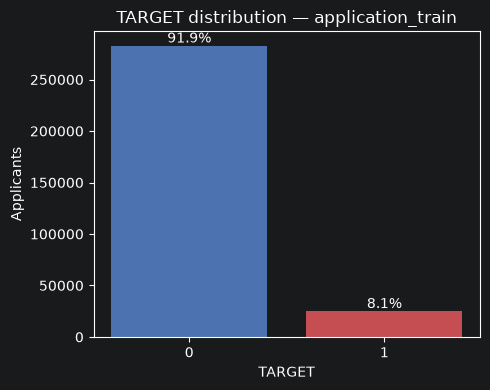

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    target_summary["TARGET"].astype(str),
    target_summary["count"],
    color=["#4C72B0", "#C44E52"],
)
ax.set_xlabel("TARGET")
ax.set_ylabel("Applicants")
ax.set_title("TARGET distribution — application_train")
for bar, pct in zip(bars, target_summary["percentage"], strict=True):
    ax.annotate(
        f"{pct:.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()

### Implications of the imbalance

- ~91.9% of applicants repay without difficulty; ~8.1% show payment difficulty — roughly an **11:1** imbalance.
- This is exactly why `HC-M1-01` rules out accuracy as the primary metric: a model predicting `TARGET = 0` for every applicant scores ~91.9% accuracy while providing zero ability to identify risk — accuracy can't distinguish that model from a genuinely useful one.
- It's also why the split (next milestone step) must be **stratified** — an unstratified random split risks a validation fold with a meaningfully different positive rate than training, which would make the validation ROC-AUC an unreliable estimate of generalization.
- The imbalance is not severe enough to require resampling (SMOTE, undersampling) as a first move — `class_weight="balanced"` in the baseline model is the right first lever, per the `senior-ml-workflow` skill's guidance to prefer class weighting before reaching for resampling.

## Summary — HC-M1-02 / HC-M1-03 / HC-M1-04 acceptance criteria

**HC-M1-02 — Dataset structure analysis**
- [x] All 8 major tables identified (plus `sample_submission`)
- [x] Row/column counts recorded (table inventory above)
- [x] Key columns identified (`primary_key_check` / `foreign_key_checks` per table, [`reports/data_quality_summary.md`](../reports/data_quality_summary.md))
- [x] `TARGET` identified (`application_train` only)
- [x] Train/test difference documented (`TARGET` is the only schema difference)
- [x] Relationships between tables documented, including all non-obvious joins (`bureau_balance → bureau` ~5.3% orphans; `SK_ID_PREV → previous_application` 3.9–10.9% orphans across the three history tables)

**HC-M1-03 — Data quality assessment**
- [x] Missing values (per-table worst offenders)
- [x] Duplicates (0 full-row duplicates across **all 9** tables — persisted in the profiler, not an ad hoc check)
- [x] Suspicious values (`DAYS_EMPLOYED` sentinel, confirmed and explained)
- [x] Constant columns (`application_test`'s 11 constant `FLAG_DOCUMENT_*` columns — a train/test shift worth watching)
- [x] Extreme values (visible directly in the numeric `min`/`max`/`median` spread in the profile, e.g. `DAYS_EMPLOYED`)
- [x] Data types (`numeric_cols` / `categorical_cols` split per table)
- [x] Categorical cardinality (all categorical columns are low-cardinality; none need target/hash encoding)

**HC-M1-04 — Target distribution**
- [x] Target counts calculated
- [x] Target percentages calculated
- [x] Imbalance documented (~11:1)
- [x] Visualization created
- [x] Implications discussed (metric choice, stratified split, class weighting)

In [17]:
con.close()